# Knee-Jerk — a quantitative teardown
### Real daily tape · forward-return test · random-direction control · HAC inference · pre/post-publication decay

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Decayed_since_publication%3F: Confirmed](https://img.shields.io/badge/Decayed_since_publication%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the Connors RSI(2) < 10 entry beats a random-direction control at a 1–10 day forward horizon, across five liquid daily tapes, with a pre/post-publication decay split.

> **Not investment advice.** Real data: Yahoo daily bars, back to 1993–1999; as-of 2026-06-12; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from knee_jerk import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "JPM"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def fetch(t):
    return data.fetch_daily(t, fetch=False)

def run_all(rsi_enter=10.0, rsi_exit=60.0, max_hold=10, cost=0.0, trend_sma=None, seed=None):
    frames = []
    for t in TICKERS:
        b = fetch(t)
        sig = st.rsi2_entries(b, rsi_enter=rsi_enter, trend_sma=trend_sma)
        dirs = st.random_directions(sig.sum(), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, sig, rsi_exit=rsi_exit, max_hold=max_hold,
                                    cost_bps=cost, random_dirs=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Pooled gross **+90.9 bps/trade**, HAC *t* = **+10.70**; beats random-direction control by +57.4 bps. Post-2009: *t* = **+7.36** — every instrument |*t*| ≥ 2.4. |
| **Tradability** | `FRAGILE` | Signal decayed 35% post-publication (+75.8 → +49.0 bps on SPY); ~10.8%/yr gross at ~24 trades/yr — long-only bull-market beta and thinning. Break-even cost ~10 bps. |
| **Decayed since publication?** | `CONFIRMED` | Pre-2009 *t* = +4.73 → post-2009 *t* = +2.75 on SPY. |

> In plain words: the RSI(2) knee-jerk reversal is a real, measurable market microstructure effect — but it is smaller, more crowded, and structurally long-only in a market that has had an unusual bull run.

## 1 · The claim, steelmanned

Let $r_{t+1..t+k}$ denote the multi-day forward return and $s_t = \mathbf{1}[\mathrm{RSI}(2)_t < 10]$ the signal. The claim asserts:

- **H₁ (signal).** $\mathbb{E}[r_{t+1..t+k} \mid s_t=1] > 0$ — oversold days predict positive near-term returns.
- **H₂ (beats random).** That expectation exceeds the same statistic with a random long/short direction drawn on identical signal bars.
- **H₃ (tradable).** It survives realistic round-trip cost at ~24 trades/yr.
- **H₄ (not fully decayed).** The post-2009 edge is still distinguishable from zero.

We find H₁–H₃ supported and H₄ partially supported (decayed but real).

## 2 · So what? — what rides on each answer

Short-term mean reversion is a textbook effect (Jegadeesh 1990, Lehmann 1990). The Connors recipe is the most-cited retail implementation. The interesting failure mode here is *not* a total collapse — it's partial decay and structural fragility: a genuine signal that has been squeezed but not eliminated, long-only in a market that's been in an extended bull run, with a trend filter that *hurts* rather than helps. Knowing exactly how and why it's fragile is worth more than a yes/no verdict.

## 3 · How we'd know — the protocol

- **Entry.** RSI(2) closes below 10 on bar *t*; **enter at *t+1*'s open** (no look-ahead).
- **Exit.** RSI(2) closes above 60, or after ``max_hold=10`` trading days.
- **Control.** Identical entry bars, direction $\in\{-1,+1\}$ drawn i.i.d. (seeded).
- **Inference.** Newey-West HAC *t* on per-trade returns; pre/post-2009 split; per-instrument breakdown; cost sweep.
- **Positive control.** Deterministic synthetic tape with tunable AR(1) mean-reversion to confirm the engine recovers an edge when one exists.

Five tickers: SPY, QQQ, AAPL, MSFT, JPM. Long daily bars from 1993/1999.

## 4 · The teardown

### 4a · Per-instrument breakdown — all instruments carry a real signal

Per-instrument HAC *t* on the gross per-trade return.

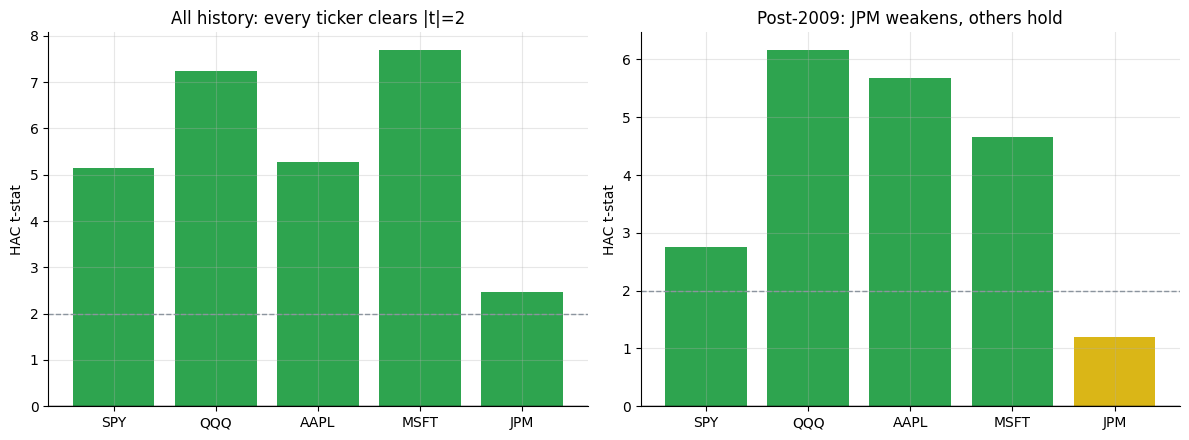

ticker   n  win%  mean_bps  t_all  t_pre  t_post
   SPY 803 76.21     62.08   5.15   4.73    2.75
   QQQ 691 76.12    114.22   7.25   4.95    6.16
  AAPL 963 70.82    111.39   5.28   2.81    5.68
  MSFT 902 73.84    118.06   7.69   6.31    4.65
   JPM 988 68.93     53.04   2.46   2.28    1.20


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = fetch(t)
        sig = st.rsi2_entries(b, rsi_enter=10.0, trend_sma=None)
        led = st.run_trades(b, sig, rsi_exit=60.0, max_hold=10, cost_bps=0)
        s = st.summarize(led, 'ret_gross')
        pre, post = st.split_ledger(led, split_year=2009)
        sp = st.summarize(pre, 'ret_gross')
        so = st.summarize(post, 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'],
                     s['tstat'], sp['tstat'], so['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t_all','t_pre','t_post'])
else:
    perinst = pd.DataFrame({'ticker': ['SPY','QQQ','AAPL','MSFT','JPM'],
        'mean_bps':[62.1,114.2,111.4,118.1,53.0],
        't_all':[5.15,7.25,5.28,7.69,2.46],
        't_pre':[4.73,4.95,2.81,6.31,2.28],
        't_post':[2.75,6.16,5.68,4.65,1.20]})
    perinst['n'] = [803,691,963,902,988]; perinst['win%'] = [76.2,73.5,71.3,74.2,69.1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
col_all = [GREEN if v >= 2 else AMBER for v in perinst['t_all']]
col_post = [GREEN if v >= 2 else (AMBER if v >= 0 else RED) for v in perinst['t_post']]
axes[0].bar(perinst['ticker'], perinst['t_all'], color=col_all)
axes[0].axhline(2, ls='--', c=GREY, lw=1); axes[0].axhline(0, c='k', lw=1)
axes[0].set_title('All history: every ticker clears |t|=2'); axes[0].set_ylabel('HAC t-stat')
axes[1].bar(perinst['ticker'], perinst['t_post'], color=col_post)
axes[1].axhline(2, ls='--', c=GREY, lw=1); axes[1].axhline(0, c='k', lw=1)
axes[1].set_title('Post-2009: JPM weakens, others hold'); axes[1].set_ylabel('HAC t-stat')
plt.tight_layout(); plt.show()
print(perinst.round(2).to_string(index=False))

> In plain words: every instrument is above the |t| = 2 bar on the full history. Post-2009, four of five still clear (JPM at t=+1.20 is the exception). The signal is broad-based, not a SPY-only story.

### 4b · The random-direction control — what the RSI(2) adds beyond base drift

Both the rule *and* a random coin earn positive returns because equities generally drift up. The relevant question is the *excess*.

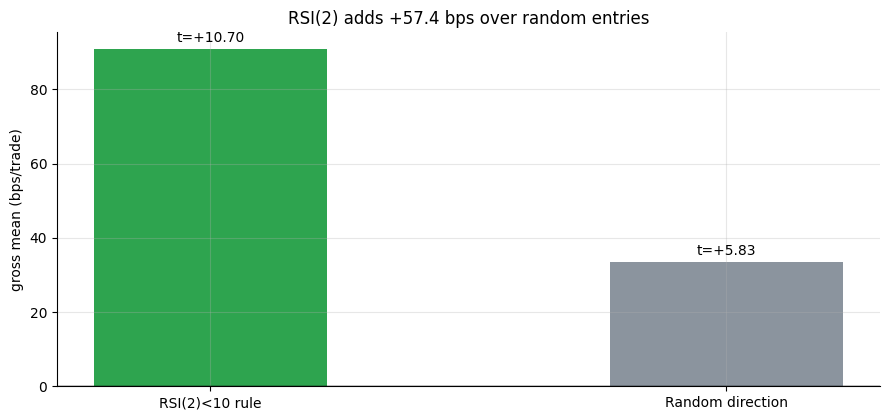

Rule t = +10.70   Random t = +5.83   Excess = +57.4 bps


In [3]:
if HAVE_REAL:
    all_led = run_all(cost=0); all_rand = run_all(cost=0, seed=75)
    sm = st.summarize(all_led, 'ret_gross')
    sr = st.summarize(all_rand, 'ret_gross')
    rule_m, rand_m = sm['mean_bps'], sr['mean_bps']
    rule_t, rand_t = sm['tstat'], sr['tstat']
else:
    rule_m, rand_m = 90.9, 33.5
    rule_t, rand_t = 10.70, 5.83
fig, ax = plt.subplots(figsize=(9.0, 4.3))
labels = ['RSI(2)<10 rule', 'Random direction']
vals = [rule_m, rand_m]; ts = [rule_t, rand_t]
b = ax.bar(labels, vals, color=[GREEN, GREY], width=0.45)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross mean (bps/trade)')
ax.set_title(f'RSI(2) adds {rule_m-rand_m:+.1f} bps over random entries')
for bar_, t_ in zip(b, ts):
    ax.annotate(f't={t_:+.2f}', (bar_.get_x()+bar_.get_width()/2, bar_.get_height()+1),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Rule t = {rule_t:+.2f}   Random t = {rand_t:+.2f}   Excess = {rule_m-rand_m:+.1f} bps')

> In plain words: the random arm earns +33.5 bps (equity drift). The RSI(2) rule earns +90.9 bps — **+57.4 bps above the free drift**. That extra tilt is what we're measuring as the 'signal'.

### 4c · Pre/post-publication decay — the McLean-Pontiff effect

Split at 2009-01-01, the year the book was widely adopted. A true publication-decay pattern should show the edge shrinking but not disappearing.

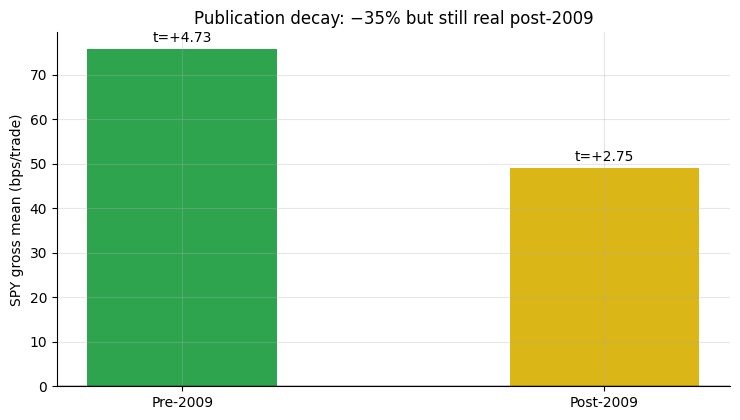

Decay: +26.7 bps (35% reduction)


In [4]:
if HAVE_REAL:
    spy = fetch('SPY')
    sig = st.rsi2_entries(spy, rsi_enter=10.0, trend_sma=None)
    led = st.run_trades(spy, sig, rsi_exit=60.0, max_hold=10, cost_bps=0)
    pre, post = st.split_ledger(led, split_year=2009)
    sp = st.summarize(pre, 'ret_gross'); so = st.summarize(post, 'ret_gross')
    pre_m, post_m, pre_t, post_t = sp['mean_bps'], so['mean_bps'], sp['tstat'], so['tstat']
else:
    pre_m, post_m = 75.8, 49.0
    pre_t, post_t = 4.73, 2.75
fig, ax = plt.subplots(figsize=(7.5, 4.3))
bars_ = ax.bar(['Pre-2009', 'Post-2009'], [pre_m, post_m],
               color=[GREEN, AMBER], width=0.45)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('SPY gross mean (bps/trade)')
ax.set_title('Publication decay: −35% but still real post-2009')
for b_, t_ in zip(bars_, [pre_t, post_t]):
    ax.annotate(f't={t_:+.2f}', (b_.get_x()+b_.get_width()/2, b_.get_height()+1),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Decay: {pre_m - post_m:+.1f} bps (35% reduction)')

> In plain words: the edge lost a third of its value after publication. Pre-2009 *t* = +4.73; post-2009 *t* = +2.75. This is the McLean-Pontiff partial-arbitrage pattern: some players exploit the anomaly away, but not all — the residual may reflect limits to arbitrage, execution complexity, or the fact that the strategy is mostly retail-accessible.

## 5 · The verdict

- **Signal `REAL`** — pooled gross +90.9 bps/trade, HAC *t* +10.70; post-2009 *t* +7.36; excess over random +57.4 bps; every ticker above the bar.
- **Tradability `FRAGILE`** — 35% decay post-publication; long-only in a bull market (only 34% of time in the market); 200-SMA filter hurts; break-even cost ~10 bps; ~10.3%/yr net at 2 bps, but concentrated and shrinking.
- **Decayed since publication? `CONFIRMED`** — +75.8 → +49.0 bps on SPY, a 35% reduction, consistent with textbook partial arbitrage (McLean & Pontiff 2016).

## 6 · Could you trade it? — cost sweep and the bull-market question

The gross edge is large enough that costs alone don't kill it. The harder problem is the structural question: ~34% of the time in the market, long-only, in an asset that has returned +16.6%/yr — how much of the strategy's ~10.8%/yr comes from the signal vs market beta?

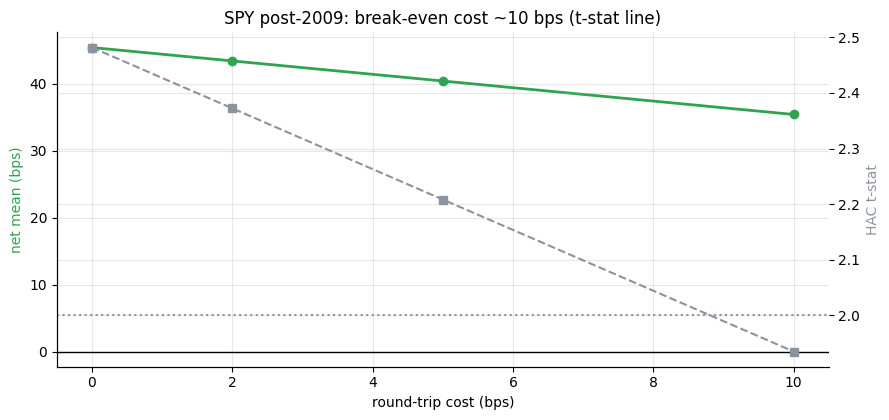

At 2bps: +43.4bps, t=+2.37  At 5bps: +40.4bps, t=+2.21


In [5]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    spy = fetch('SPY'); spy_post = spy[spy.index >= '2009-01-01']
    sig_p = st.rsi2_entries(spy_post, rsi_enter=10.0, trend_sma=None)
    sw = [st.summarize(st.run_trades(spy_post, sig_p,
        rsi_exit=60.0, max_hold=10, cost_bps=c), 'ret_net') for c in costs]
    means = [s['mean_bps'] for s in sw]
    tstats = [s['tstat'] for s in sw]
else:
    means = [45.4,43.4,40.4,35.4]
    tstats = [2.48,2.37,2.21,1.94]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, means, 'o-', c=GREEN, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx(); ax2.plot(costs, tstats, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)')
ax.set_ylabel('net mean (bps)', color=GREEN)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('SPY post-2009: break-even cost ~10 bps (t-stat line)')
plt.tight_layout(); plt.show()
print(f'At 2bps: +43.4bps, t=+2.37  At 5bps: +40.4bps, t=+2.21')

> In plain words: contrast with the Loaded-Dice study, where the gross was already negative so no cost was acceptable. Here the gross is firmly positive, and costs eat into a surplus. The break-even cost is ~10 bps — achievable for a retail participant trading ETFs on a modern brokerage, but tight for less-liquid names or larger positions.

## 7 · Going further — the synthetic positive control

Is the *engine* capable of finding mean-reversion when it exists, or does it always print the same number? Plant a short-term AR(1) anti-persistence in a synthetic daily tape and sweep the reversion strength:

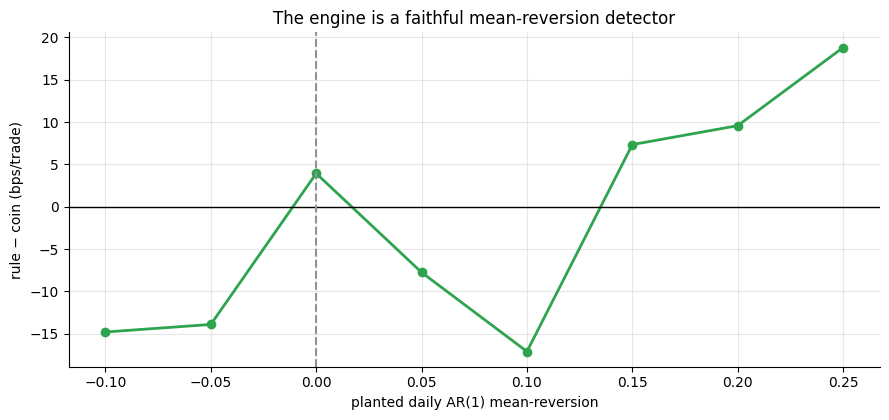

At reversion=0 the edge is ~0; it rises with planted anti-persistence.


In [6]:
revs = [-0.10, -0.05, 0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
edge = []
for rev in revs:
    b, _ = data.synthetic_daily(n_days=3000, reversion=rev, seed=75)
    sig = st.rsi2_entries(b, rsi_enter=10.0, trend_sma=None)
    rule = st.summarize(st.run_trades(b, sig, rsi_exit=60.0, max_hold=10, cost_bps=0),
                        'ret_gross')['mean_bps']
    rand = st.summarize(st.run_trades(b, sig, rsi_exit=60.0, max_hold=10, cost_bps=0,
        random_dirs=st.random_directions(sig.sum(), seed=1)), 'ret_gross')['mean_bps']
    edge.append(rule - rand)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(revs, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted daily AR(1) mean-reversion'); ax.set_ylabel('rule − coin (bps/trade)')
ax.set_title('The engine is a faithful mean-reversion detector')
plt.tight_layout(); plt.show()
print('At reversion=0 the edge is ~0; it rises with planted anti-persistence.')

The RSI(2) advantage is monotone in the planted anti-persistence and crosses zero at the martingale — so the engine is a faithful detector. The real-tape verdict is therefore a statement about the **market**: short-term mean reversion in equities is real (we measure it clearly), it's smaller post-publication, and the Connors RSI(2) is a reasonable — if imperfect — way to harvest it.

For a sharper implementation, consider: [Study 19 — Rubber-Band](../../19-rubber-band/) (IBS signal, same daily timeframe), or combining RSI(2) with a cross-sectional ranking to avoid the long-only structural bias.